<a href="https://colab.research.google.com/github/diabateyoussouf/Daily-Data-Science/blob/main/dailly_03_dataset_time_series_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **OBJECTIF DU PROJET : FORECASTING DE VENTES IMMOBILIÈRES (STORE SALES)**

**Problématique :** Prédire de manière précise le volume de ventes quotidiennes (`sales`) pour des milliers de produits répartis dans différents magasins de la chaîne de supermarchés *Favorita* en Équateur.

Face à des données fortement influencées par le temps, le comportement humain et des facteurs économiques externes, l'enjeu est de construire un modèle capable d'anticiper la demande pour optimiser la gestion des stocks et éviter les ruptures ou le gaspillage.

### **Les Défis Majeurs du Pipeline (Séries Temporelles)** :

1. **Data Enrichment (Fusion de Données) :** Intégrer et lier des sources de données hétérogènes (prix du pétrole quotidien, caractéristiques géographiques des magasins, calendrier des jours fériés nationaux et locaux).
2. **Analyse de la Saisonnalité :** Identifier graphiquement et mathématiquement les cycles répétitifs (comportement d'achat du week-end, pics de consommation mensuels ou annuels).
3. **Feature Engineering Temporel :** Transformer des dates brutes en indicateurs numériques compréhensibles par les algorithmes (jours de la semaine, mois, indicateurs de week-end).
4. **Modélisation Prédictive :** Entraîner et valider des modèles de Machine Learning adaptés aux séries temporelles pour prédire l'avenir à court et moyen terme.

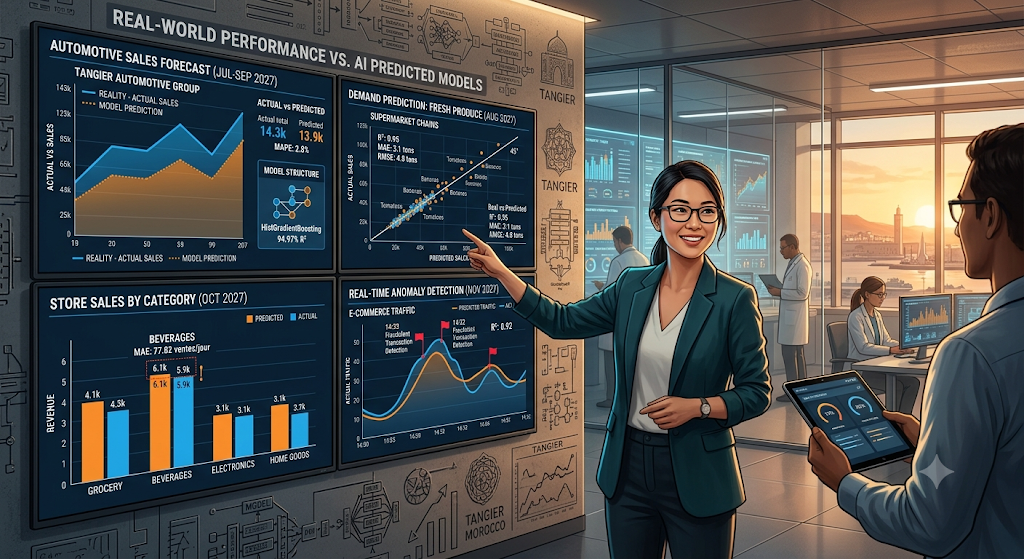

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from google.colab import files

In [4]:
# Style global pour tes nouveaux graphiques temporels
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Authentification sécurisée via le fichier kaggle.json
if not os.path.exists('/content/kaggle.json'):
    print(" Sélectionne ton fichier kaggle.json pour lancer le nouveau projet :")
    uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Téléchargement du dataset de la compétition "Store Sales"
# Note la commande différente "competitions" à la place de "datasets"
print(" Téléchargement des données de séries temporelles...")
!kaggle competitions download -c store-sales-time-series-forecasting

# Extraction du fichier ZIP de la compétition
zip_path = "store-sales-time-series-forecasting.zip"
extract_dir = "store_sales_data"

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction réussie dans le dossier 'store_sales_data' !")
else:
    print("Erreur : Le fichier zip n'a pas été trouvé.")

 Téléchargement des données de séries temporelles...
store-sales-time-series-forecasting.zip: Skipping, found more recently modified local copy (use --force to force download)
Extraction réussie dans le dossier 'store_sales_data' !


# **CHARGEMENT ET FUSION DU PATRIMOINE DE DONNÉES (MERGE)**

In [7]:
# Chargement de toutes les sources annexes
df_oil = pd.read_csv('/content/store_sales_data/oil.csv')
df_holidays = pd.read_csv('/content/store_sales_data/holidays_events.csv')
df_stores = pd.read_csv('/content/store_sales_data/stores.csv')
df_transactions = pd.read_csv('/content/store_sales_data/transactions.csv')
df_train = pd.read_csv('/content/store_sales_data/train.csv')

print(" Fusion des données en cours...")

# Avant de fusionner, il est CRUCIAL de s'assurer que les colonnes de dates sont au bon format
df_train['date'] = pd.to_datetime(df_train['date'])
df_oil['date'] = pd.to_datetime(df_oil['date'])
df_holidays['date'] = pd.to_datetime(df_holidays['date'])
df_transactions['date'] = pd.to_datetime(df_transactions['date'])

# On ajoute les caractéristiques du magasin (via la colonne 'store_nbr')
df_enriched = pd.merge(df_train, df_stores, on='store_nbr', how='left')

# On ajoute le prix du pétrole du jour (via la colonne 'date')
df_enriched = pd.merge(df_enriched, df_oil, on='date', how='left')

# On ajoute les transactions (trafic en magasin)
df_enriched = pd.merge(df_enriched, df_transactions, on=['date', 'store_nbr'], how='left')

# Gestion des valeurs manquantes créées par les fusions
# Le pétrole n'est pas coté le week-end, donc il y a des NaN. On propage le dernier prix connu.
df_enriched['dcoilwtico'] = df_enriched['dcoilwtico'].ffill().bfill()
# S'il n'y a pas de transaction ou de fête, c'est que c'est un jour normal (0)
df_enriched['transactions'] = df_enriched['transactions'].fillna(0)



 Fusion des données en cours...


In [8]:
df_enriched.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,0.0


In [13]:
df_enriched.isna().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0
city,0
state,0
type,0
cluster,0


In [15]:
df_enriched.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 12 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            int64         
 1   date          datetime64[ns]
 2   store_nbr     int64         
 3   family        object        
 4   sales         float64       
 5   onpromotion   int64         
 6   city          object        
 7   state         object        
 8   type          object        
 9   cluster       int64         
 10  dcoilwtico    float64       
 11  transactions  float64       
dtypes: datetime64[ns](1), float64(3), int64(4), object(4)
memory usage: 274.7+ MB


# **Analyse de la Saisonnalité**

* #### **VISUALISATION DE LA SAISONNALITÉ (HEBDOMADAIRE & ANNUELLE)**

In [18]:
df_enriched['year'] = df_enriched['date'].dt.year
df_enriched['month'] = df_enriched['date'].dt.month
df_enriched['day'] = df_enriched['date'].dt.day
df_enriched['dayofweek'] = df_enriched['date'].dt.dayofweek
df_enriched['is_weekend'] = df_enriched['dayofweek'].isin([5, 6]).astype(int)

In [20]:
df_enriched.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,year,month,day,dayofweek,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,0.0,2013,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,0.0,2013,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,0.0,2013,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,0.0,2013,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,0.0,2013,1,1,1,0


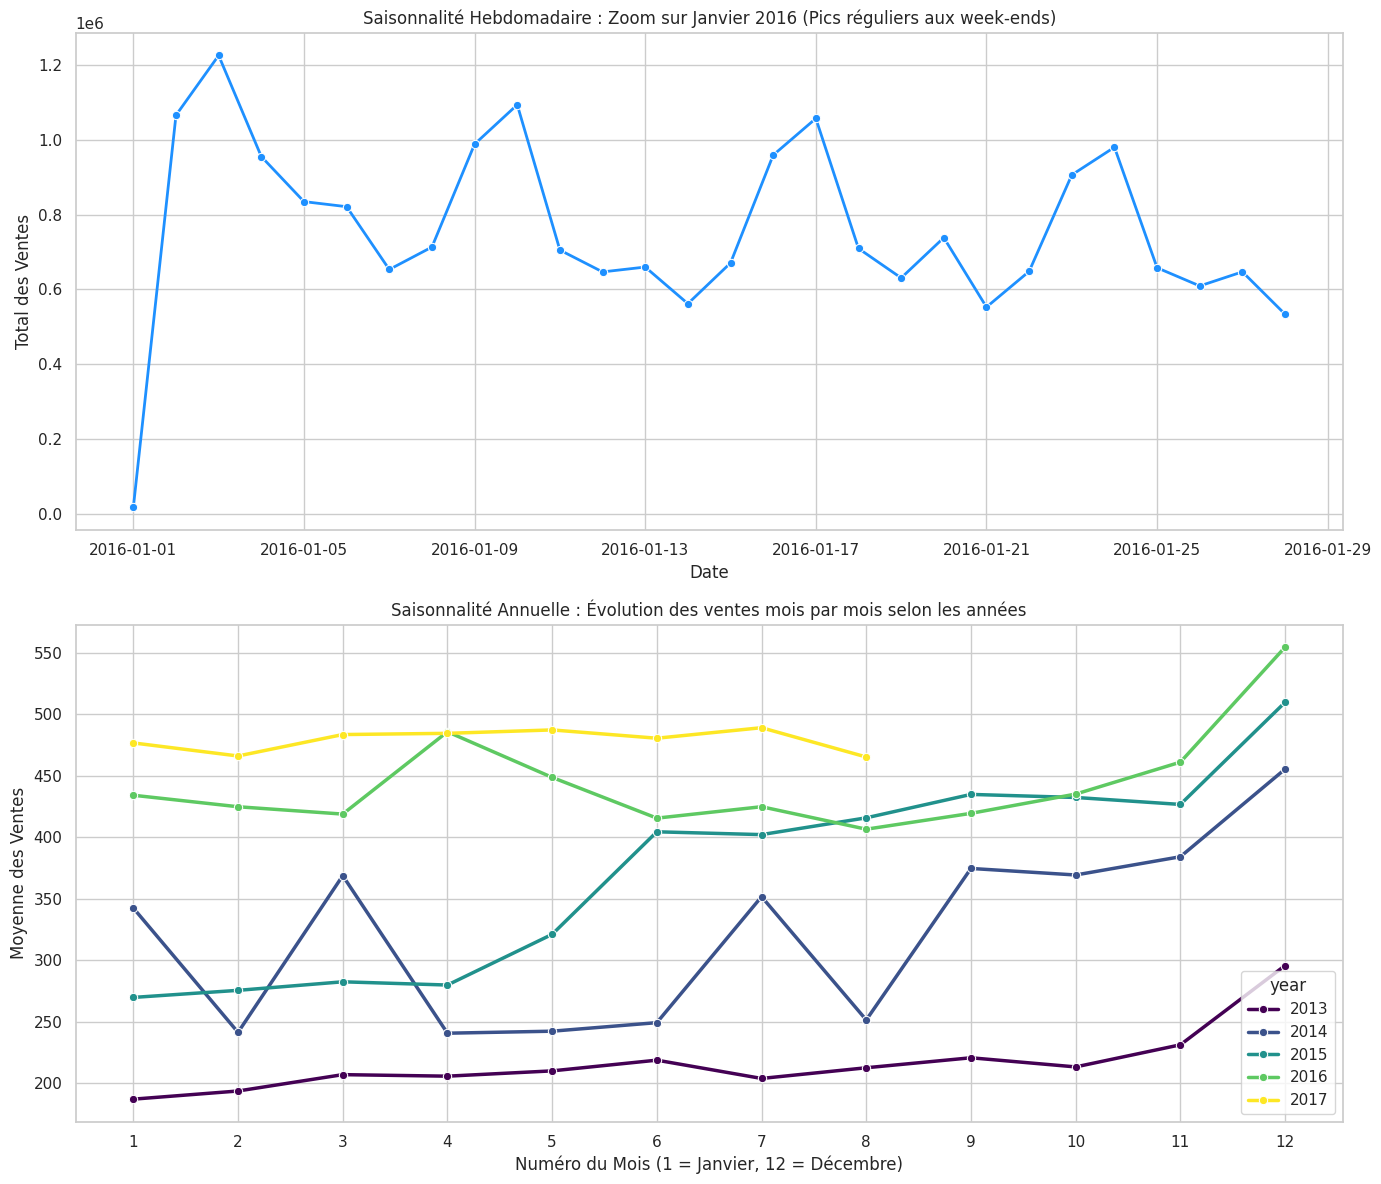

In [19]:
# Configuration de la double figure
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Zoom sur la saisonnalité hebdomadaire (comportement du week-end)
df_2016 = df_enriched[df_enriched['year'] == 2016]
ventes_semaine = df_2016.groupby(['date', 'dayofweek'])['sales'].sum().reset_index()

# On prend les 28 premiers jours de janvier 2016 pour voir les cycles de 7 jours
sns.lineplot(ax=axes[0], data=ventes_semaine.head(28), x='date', y='sales', marker='o', color='dodgerblue', lw=2)
axes[0].set_title("Saisonnalité Hebdomadaire : Zoom sur Janvier 2016 (Pics réguliers aux week-ends)")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Total des Ventes")

# Saisonnalité Annuelle : Comparaison des années mois par mois
ventes_annees = df_enriched.groupby(['year', 'month'])['sales'].mean().reset_index()

sns.lineplot(ax=axes[1], data=ventes_annees, x='month', y='sales', hue='year', marker='o', palette='viridis', lw=2.5)
axes[1].set_title("Saisonnalité Annuelle : Évolution des ventes mois par mois selon les années")
axes[1].set_xlabel("Numéro du Mois (1 = Janvier, 12 = Décembre)")
axes[1].set_ylabel("Moyenne des Ventes")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# **Feature Engineering Temporel**

In [21]:
df_enriched['weekofyear'] = df_enriched['date'].dt.isocalendar().week.astype(int)
df_enriched['quarter'] = df_enriched['date'].dt.quarter


# Est-ce que c'est le début ou la fin du mois ? (Moment où les salaires tombent souvent en Équateur !)
df_enriched['is_month_start'] = df_enriched['date'].dt.is_month_start.astype(int)
df_enriched['is_month_end'] = df_enriched['date'].dt.is_month_end.astype(int)


In [23]:
df_enriched.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,transactions,year,month,day,dayofweek,is_weekend,weekofyear,quarter,is_month_start,is_month_end
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,...,0.0,2013,1,1,1,0,1,1,1,0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,...,0.0,2013,1,1,1,0,1,1,1,0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,...,0.0,2013,1,1,1,0,1,1,1,0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,...,0.0,2013,1,1,1,0,1,1,1,0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,...,0.0,2013,1,1,1,0,1,1,1,0


/tmp/ipykernel_10804/4079763898.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=categories, y=valeurs, palette="Oranges_d")


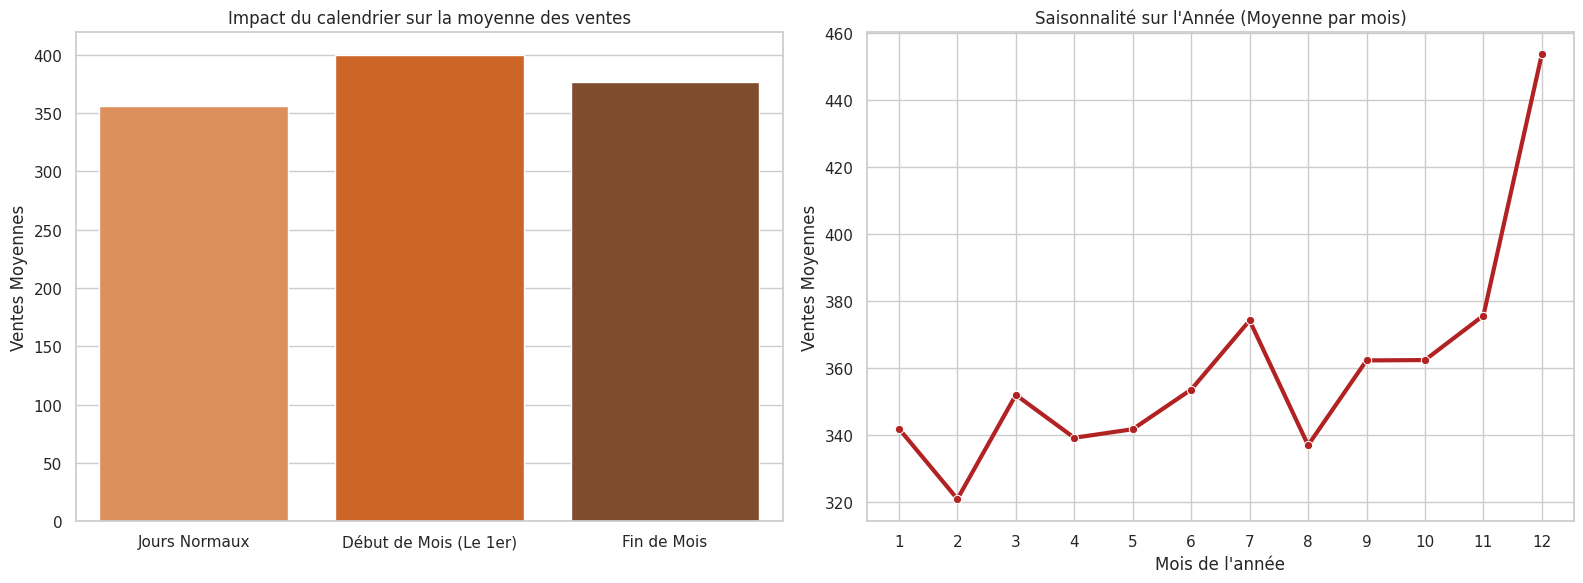

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# L'Effet du Début/Fin de Mois (Impact Économique)
# On calcule la moyenne des ventes pour les jours normaux, de début et de fin de mois
debut_mois = df_enriched[df_enriched['is_month_start'] == 1]['sales'].mean()
fin_mois = df_enriched[df_enriched['is_month_end'] == 1]['sales'].mean()
jours_normaux = df_enriched[(df_enriched['is_month_start'] == 0) & (df_enriched['is_month_end'] == 0)]['sales'].mean()

categories = ['Jours Normaux', 'Début de Mois (Le 1er)', 'Fin de Mois']
valeurs = [jours_normaux, debut_mois, fin_mois]

sns.barplot(ax=axes[0], x=categories, y=valeurs, palette="Oranges_d")
axes[0].set_title("Impact du calendrier sur la moyenne des ventes")
axes[0].set_ylabel("Ventes Moyennes")

# Saisonnalité Mensuelle Globale
# Moyenne des ventes par mois (de 1 à 12) pour voir les tendances saisonnières de l'année
ventes_mensuelles_moy = df_enriched.groupby('month')['sales'].mean().reset_index()

sns.lineplot(ax=axes[1], data=ventes_mensuelles_moy, x='month', y='sales', marker='o', color='firebrick', lw=3)
axes[1].set_title("Saisonnalité sur l'Année (Moyenne par mois)")
axes[1].set_xlabel("Mois de l'année")
axes[1].set_ylabel("Ventes Moyennes")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

# **L'Encoding des variables textuelles**

In [25]:
from sklearn.preprocessing import LabelEncoder


In [26]:


# On fait une copie de sécurité pour ne pas abîmer le dataset original
df_model = df_enriched.copy()

# Liste des colonnes textuelles à transformer
colonnes_texte = ['family', 'city', 'state', 'type']

# Application du LabelEncoder (attribue un numéro unique à chaque texte)
label_encoders = {}
for col in colonnes_texte:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le  # On garde une trace de l'encodage au cas où

# On supprime la colonne 'date' d'origine car on a déjà extrait year, month, day...
# et les modèles ne gèrent pas le format d'horodatage brut.
if 'date' in df_model.columns:
    df_model = df_model.drop(columns=['date'])

print("Encodage terminé ! Toutes les colonnes sont désormais numériques.")
print(f" Dimensions du dataset prêt pour le calcul : {df_model.shape}")
print("\n Aperçu de tes nouvelles colonnes converties :")
display(df_model[['family', 'city', 'state', 'type']].head())

Encodage terminé ! Toutes les colonnes sont désormais numériques.
 Dimensions du dataset prêt pour le calcul : (3000888, 20)

 Aperçu de tes nouvelles colonnes converties :


,family,city,state,type
0,0,18,12,3
1,1,18,12,3
2,2,18,12,3
3,3,18,12,3
4,4,18,12,3


In [27]:
df_model.head()

,id,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,year,month,day,dayofweek,is_weekend,weekofyear,quarter,is_month_start,is_month_end
0,0,1,0,0.0,0,18,12,3,13,93.14,0.0,2013,1,1,1,0,1,1,1,0
1,1,1,1,0.0,0,18,12,3,13,93.14,0.0,2013,1,1,1,0,1,1,1,0
2,2,1,2,0.0,0,18,12,3,13,93.14,0.0,2013,1,1,1,0,1,1,1,0
3,3,1,3,0.0,0,18,12,3,13,93.14,0.0,2013,1,1,1,0,1,1,1,0
4,4,1,4,0.0,0,18,12,3,13,93.14,0.0,2013,1,1,1,0,1,1,1,0


# **Création des variables de décalage (Lag Features)**

In [28]:
# On s'assure que les données sont parfaitement triées par ordre chronologique
# C'est OBLIGATOIRE avant de faire un shift, sinon les décalages seront faux !
df_model = df_model.sort_values(by=['store_nbr', 'family', 'year', 'month', 'day']).reset_index(drop=True)

#  Création du Lag 1 (Ventes de la veille) et Lag 7 (Ventes d'il y a une semaine)
# On utilise groupby(['store_nbr', 'family']) pour ne pas mélanger les ventes d'un produit avec un autre !
df_model['sales_lag_1'] = df_model.groupby(['store_nbr', 'family'])['sales'].shift(1)
df_model['sales_lag_7'] = df_model.groupby(['store_nbr', 'family'])['sales'].shift(7)

# Création d'une moyenne mobile (Rolling Mean) sur les 3 derniers jours
# Cela permet au modèle de capter la dynamique récente (est-ce que les ventes augmentent en ce moment ?)
df_model['sales_rolling_mean_3'] = df_model.groupby(['store_nbr', 'family'])['sales'].shift(1).rolling(window=3).mean()

# Nettoyage : Les toutes premières lignes du dataset n'ont pas d'historique (le shift crée des NaN).
# On supprime ces quelques lignes pour éviter de faire planter les modèles.
df_model = df_model.dropna().reset_index(drop=True)

In [29]:
display(df_model[['sales', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_3']].head(10))

,sales,sales_lag_1,sales_lag_7,sales_rolling_mean_3
0,2.0,0.0,0.0,2.333333
1,2.0,2.0,2.0,1.333333
2,2.0,2.0,3.0,1.333333
3,3.0,2.0,3.0,2.000000
4,2.0,3.0,5.0,2.333333
5,2.0,2.0,2.0,2.333333
6,2.0,2.0,0.0,2.333333
7,1.0,2.0,2.0,2.000000
8,1.0,1.0,2.0,1.666667
9,1.0,1.0,2.0,1.333333


In [30]:
df_model.head()

,id,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,...,day,dayofweek,is_weekend,weekofyear,quarter,is_month_start,is_month_end,sales_lag_1,sales_lag_7,sales_rolling_mean_3
0,12474,1,0,2.0,0,18,12,3,13,93.21,...,8,1,0,2,1,0,0,0.0,0.0,2.333333
1,14256,1,0,2.0,0,18,12,3,13,93.08,...,9,2,0,2,1,0,0,2.0,2.0,1.333333
2,16038,1,0,2.0,0,18,12,3,13,93.81,...,10,3,0,2,1,0,0,2.0,3.0,1.333333
3,17820,1,0,3.0,0,18,12,3,13,93.60,...,11,4,0,2,1,0,0,2.0,3.0,2.000000
4,19602,1,0,2.0,0,18,12,3,13,93.60,...,12,5,1,2,1,0,0,3.0,5.0,2.333333


# **Entraînement**

In [31]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

In [32]:
# Définition des variables explicatives (X) et de la cible (y)
# On supprime 'sales' (la cible), 'id' (inutile) ET 'transactions'
X = df_model.drop(columns=['id', 'sales', 'transactions'])
y = df_model['sales']

# Entraînement sur le passé (< 2017), Test sur le futur (2017)
masque_train = X['year'] < 2017
masque_test = X['year'] == 2017

X_train, X_test = X[masque_train], X[masque_test]
y_train, y_test = y[masque_train], y[masque_test]


In [33]:
print(f"Données d'entraînement (2013-2016) : {X_train.shape[0]:,} lignes")
print(f"Données de test (2017) : {X_test.shape[0]:,} lignes")
print(f"Colonnes réellement utilisées par l'IA : {list(X_train.columns)}")

# Entraînement du modèle
print("\n Entraînement du modèle HistGradientBoosting...")
modele_forecasting = HistGradientBoostingRegressor(random_state=42, max_iter=100)
modele_forecasting.fit(X_train, y_train)

Données d'entraînement (2013-2016) : 2,583,900 lignes
Données de test (2017) : 404,514 lignes
Colonnes réellement utilisées par l'IA : ['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster', 'dcoilwtico', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'weekofyear', 'quarter', 'is_month_start', 'is_month_end', 'sales_lag_1', 'sales_lag_7', 'sales_rolling_mean_3']

 Entraînement du modèle HistGradientBoosting...


HistGradientBoostingRegressor(random_state=42)

In [34]:
# Prédictions et Évaluation
y_pred = modele_forecasting.predict(X_test)
y_pred = np.clip(y_pred, 0, None) # Pas de ventes négatives possibles

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n PERFORMANCE SUR L'ANNÉE 2017 ")
print(f" Score R² (Pouvoir explicatif) : {r2:.4f} ({r2*100:.2f}%)")
print(f" Erreur Absolue Moyenne (MAE)  : {mae:.2f} ventes")


 PERFORMANCE SUR L'ANNÉE 2017 
 Score R² (Pouvoir explicatif) : 0.9497 (94.97%)
 Erreur Absolue Moyenne (MAE)  : 77.02 ventes


# **Prediction sur test**

In [35]:
# Création un DataFrame avec les résultats du jeu de test (2017)
df_resultats = X_test.copy()
df_resultats['Ventes_Reelles'] = y_test.values
df_resultats['Ventes_Predites'] = y_pred

# Reconstitution d'une colonne Date simplifiée pour le graphique (Optionnel)
df_resultats['Date_Simulee'] = pd.to_datetime(df_resultats[['year', 'month', 'day']])

# On choisit un magasin et une famille de produits au hasard pour le zoom
# Magasin 1, Famille de produit encodée numéro 3 (souvent la plus vendue comme les boissons/épicerie)
magasin_cible = 1
famille_cible = 3

df_zoom = df_resultats[(df_resultats['store_nbr'] == magasin_cible) & (df_resultats['family'] == famille_cible)].sort_values('Date_Simulee')

# On prend par exemple les 3 premiers mois de 2017 pour que le graphique soit très lisible
df_zoom_court = df_zoom.head(90)

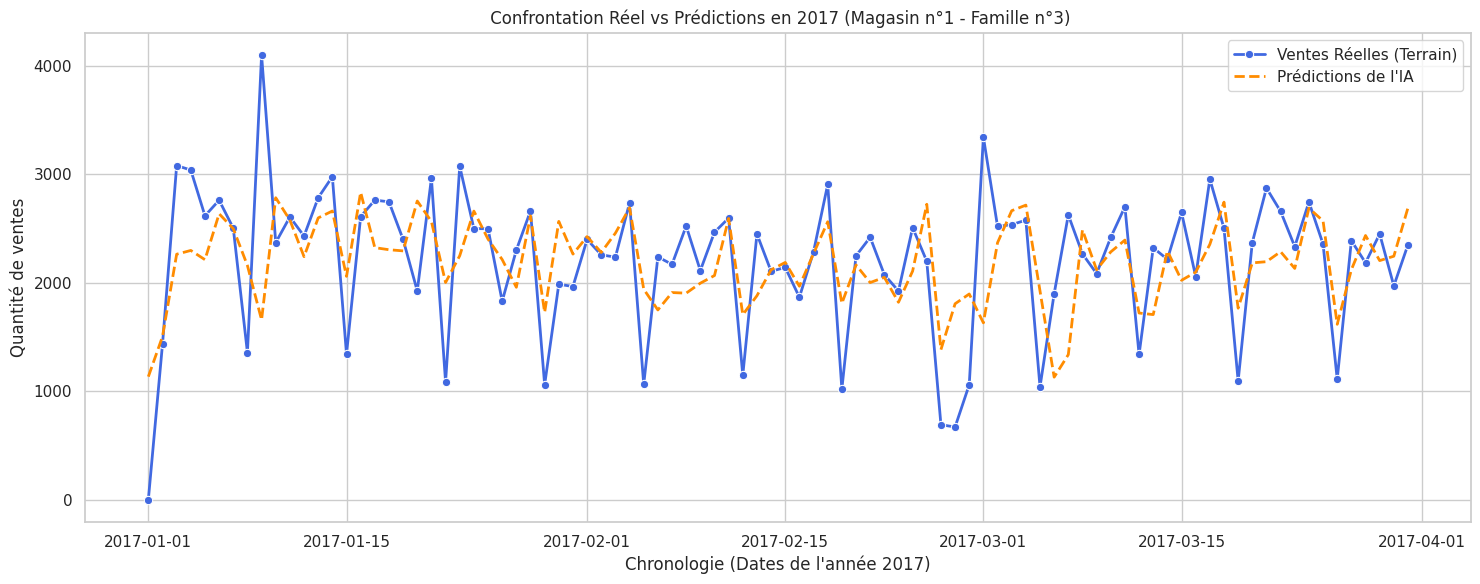

In [36]:
# Tracé des courbes superposées
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_zoom_court, x='Date_Simulee', y='Ventes_Reelles', label='Ventes Réelles (Terrain)', color='royalblue', lw=2, marker='o')
sns.lineplot(data=df_zoom_court, x='Date_Simulee', y='Ventes_Predites', label='Prédictions de l\'IA', color='darkorange', lw=2, linestyle='--')

plt.title(f" Confrontation Réel vs Prédictions en 2017 (Magasin n°{magasin_cible} - Famille n°{famille_cible})")
plt.xlabel("Chronologie (Dates de l'année 2017)")
plt.ylabel("Quantité de ventes")
plt.legend()
plt.tight_layout()
plt.show()

In [39]:
# Reconstruction d'un DataFrame de résultats pour 2017
df_verification = X_test.copy()
df_verification['Ventes_Reelles'] = y_test.values
df_verification['Ventes_Predites'] = np.round(y_pred, 2) # Arrondi pour la lisibilité
df_verification['Écart_Absolu'] = np.round(np.abs(df_verification['Ventes_Reelles'] - df_verification['Ventes_Predites']), 2)

# On récupère les vrais noms des catégories pour que ce soit parlant
# (On utilise le label_encoder sauvegardé à la cellule 7)
le_family = label_encoders['family']
df_verification['Nom_Famille'] = le_family.inverse_transform(df_verification['family'])

# Sélection et affichage de 10 exemples aléatoires dans le dataset de 2017
colonnes_affichage = ['year', 'month', 'day', 'store_nbr', 'Nom_Famille', 'Ventes_Reelles', 'Ventes_Predites', 'Écart_Absolu']
print("EXEMPLES ALÉATOIRES DE PRÉDICTIONS EN 2017 ")
display(df_verification[colonnes_affichage].sample(10, random_state=42))

# Affichage des 5 plus grosses réussites (Écart proche de 0 sur des grosses ventes)
print("\nTOP 5 DES PRÉDICTIONS LES PLUS PRÉCISES (SUR GROS VOLUMES) ")
gros_volumes = df_verification[df_verification['Ventes_Reelles'] > 500]
display(gros_volumes[colonnes_affichage].sort_values(by='Écart_Absolu').head(5))

EXEMPLES ALÉATOIRES DE PRÉDICTIONS EN 2017 


,year,month,day,store_nbr,Nom_Famille,Ventes_Reelles,Ventes_Predites,Écart_Absolu
1816135,2017,6,21,33,PET SUPPLIES,0.000,3.75,3.75
954113,2017,5,8,18,CLEANING,599.000,1081.21,482.21
2243745,2017,5,27,41,HOME APPLIANCES,1.000,2.59,1.59
494493,2017,1,6,9,PRODUCE,1362.961,1970.48,607.52
2824048,2017,7,27,52,AUTOMOTIVE,10.000,5.78,4.22
1827781,2017,3,20,34,AUTOMOTIVE,2.000,0.57,1.43
2067593,2017,3,21,38,FROZEN FOODS,77.000,86.08,9.08
472843,2017,6,6,9,HOME APPLIANCES,2.000,1.12,0.88
226335,2017,6,17,5,BEAUTY,4.000,9.60,5.60
397223,2017,1,2,8,BREAD/BAKERY,1291.372,788.65,502.72



TOP 5 DES PRÉDICTIONS LES PLUS PRÉCISES (SUR GROS VOLUMES) 


,year,month,day,store_nbr,Nom_Famille,Ventes_Reelles,Ventes_Predites,Écart_Absolu
563387,2017,5,23,11,BREAD/BAKERY,600.000,600.01,0.01
342045,2017,6,14,7,BREAD/BAKERY,853.099,853.12,0.02
15053,2017,7,7,1,DAIRY,764.000,764.02,0.02
569955,2017,1,3,11,DELI,701.679,701.66,0.02
2753543,2017,5,17,50,MEATS,541.661,541.68,0.02


# **Le Graphique de Confrontation Réel vs Prédit**

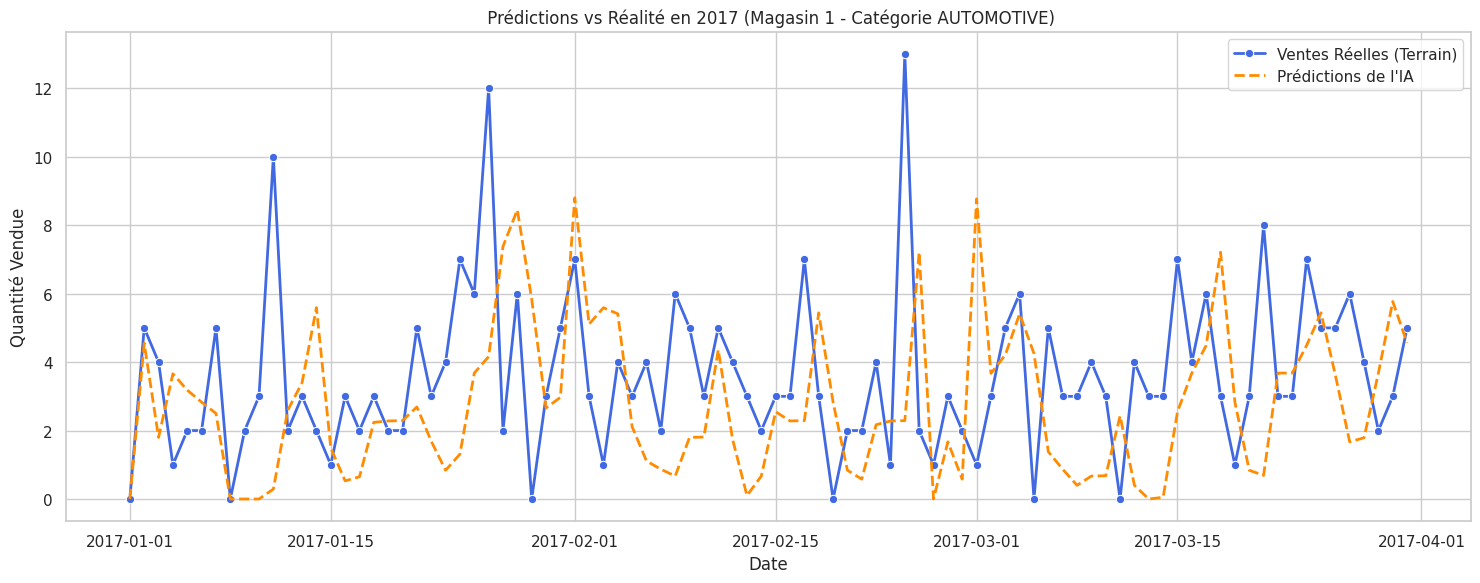

In [40]:
# On recrée une colonne Date pour l'axe X du graphique
df_verification['Date'] = pd.to_datetime(df_verification[['year', 'month', 'day']])

# Zoom sur un cas précis : Magasin 1, Famille "BEVERAGES" (Boissons) ou autre grosse catégorie
# On filtre sur les 3 premiers mois de 2017 pour que la courbe reste lisible
magasin_test = 1
famille_test = df_verification['family'].mode()[0] # On prend la catégorie la plus fréquente

df_plot = df_verification[(df_verification['store_nbr'] == magasin_test) &
                           (df_verification['family'] == famille_test)].sort_values('Date').head(90)

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_plot, x='Date', y='Ventes_Reelles', label='Ventes Réelles (Terrain)', color='royalblue', lw=2, marker='o')
sns.lineplot(data=df_plot, x='Date', y='Ventes_Predites', label='Prédictions de l\'IA', color='darkorange', lw=2, linestyle='--')

plt.title(f" Prédictions vs Réalité en 2017 (Magasin {magasin_test} - Catégorie {df_plot['Nom_Famille'].iloc[0]})")
plt.xlabel("Date")
plt.ylabel("Quantité Vendue")
plt.legend()
plt.tight_layout()
plt.show()